In [10]:
import pandas as pd
titanic=pd.read_csv('/content/train.csv')
print(titanic.head())
print(titanic.tail())



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [11]:
print(titanic.describe())
print(titanic.info())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data colu

# **Perform Exploratory Data Analysis of titanic dataset**

In [12]:
#check and handle missing values and duplicates
print(titanic.isnull().sum())

titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
titanic["Cabin"].fillna(titanic["Cabin"].mode()[0], inplace=True)
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0], inplace=True)
titanic = titanic.drop_duplicates()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/tmp/ipykernel_781/4280451798.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
/tmp/ipykernel_781/4280451798.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [13]:
titanic = titanic.drop(columns=["Cabin"])

In [14]:
print(titanic.shape)

(891, 11)


In [15]:
#count the number of male and female passengers
print(titanic["Sex"].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


<Axes: xlabel='Age', ylabel='Count'>

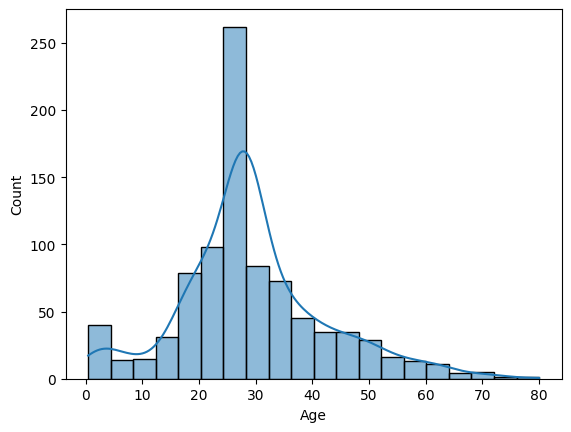

In [16]:
#Univariate analysis of Age column
import seaborn as sns
sns.histplot(titanic["Age"], bins=20, kde=True)


Most passengers are young adults
The highest bar is around 28–30 years.
This means the largest number of passengers were in this age group.
Right-skewed (positively skewed) distribution
The distribution has a long tail toward higher ages (40–80 years).
There are fewer older passengers than younger ones.
Few children and elderly passengers
There are relatively few passengers below 10 years.
There are also few passengers above 60 years.
KDE (blue smooth curve)
The blue curve is the Kernel Density Estimation (KDE).
It provides a smooth estimate of the age distribution.
Its peak is around 28 years, confirming that this is the most common age.
Wide age range
Passenger ages range from approximately 0 to 80 years.

<Axes: xlabel='Fare', ylabel='Count'>

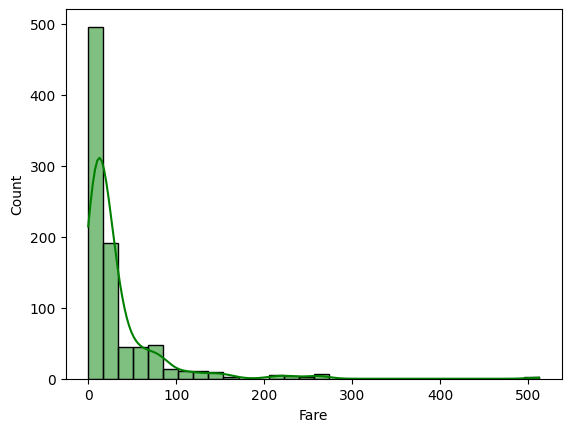

In [17]:
sns.histplot(titanic["Fare"], bins=30, kde=True, color="green")

The histogram with KDE shows that the Fare variable is highly positively (right) skewed, with most passengers paying low fares, primarily below 50. The distribution has a long right tail due to a small number of passengers who paid very high fares, indicating the presence of outliers. The KDE curve confirms that low fares are the most common, while the frequency of passengers decreases as the fare increases. Overall, the Fare feature is not normally distributed and exhibits significant skewness.

<Axes: xlabel='Sex', ylabel='count'>

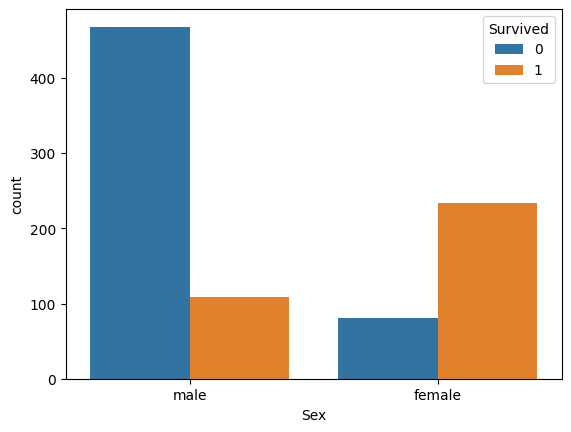

In [18]:
sns.countplot(x="Sex", hue="Survived", data=titanic)


This count plot showing distribution of survivors vs passenger sex, indicates that men had a much higher mortality rate with the vast majority not surviving the titanic disaster while women had a considerably lower mortality rate with the number of survivors exceeding fatalities. Thus we may say that predictor passenger sex is a strong surrogate variable, with females being given preference in evacuation efforts. The Sex feature is therefore expected to decision trees with respect to passenger survival predictions.

<Axes: xlabel='Pclass', ylabel='count'>

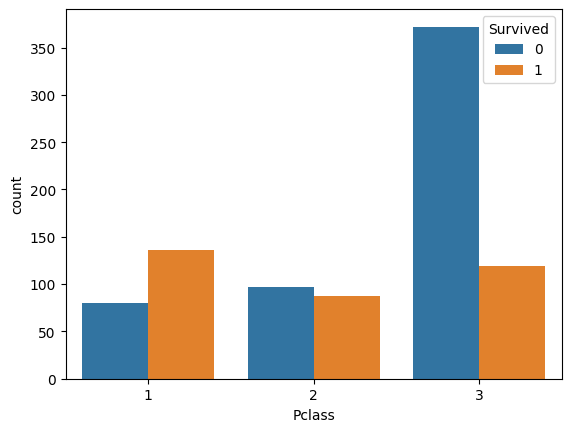

In [19]:
sns.countplot(x="Pclass", hue="Survived", data=titanic)

Passenger class is correlated with survival. The first class has the most survivors and proportionally the most with a survivor count greater than the number of non-survivors. The third class has suffered more deaths than any other group, the number of non-survivors is much greater than the survivor count. The second class seems to be more evenly spread with only negligibly more deaths than survivors. Clearly the higher the class the more likely a chance of survival, possibly linked to access to lifeboats and locations on the ship.

<Axes: xlabel='Embarked', ylabel='count'>

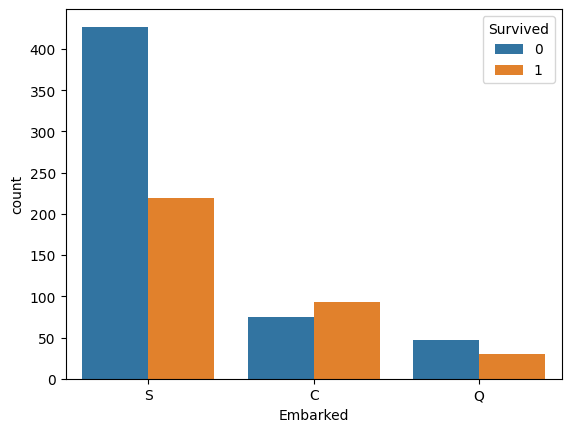

In [20]:
sns.countplot(x="Embarked", hue="Survived", data=titanic)

The port of embarkation appears to influence passenger survival. Most passengers boarded at Southampton (S), which also recorded the highest number of both survivors and non-survivors. However, because Southampton had the largest number of passengers, the high number of deaths is expected. Passengers who embarked from Cherbourg (C) show more survivors than non-survivors, indicating a relatively higher survival rate. In contrast, passengers from Queenstown (Q) had fewer passengers overall and slightly more deaths than survivors. These results suggest that the embarkation port is associated with survival, although this may also reflect differences in passenger class and ticket fare among the ports.

<Axes: xlabel='Survived', ylabel='Age'>

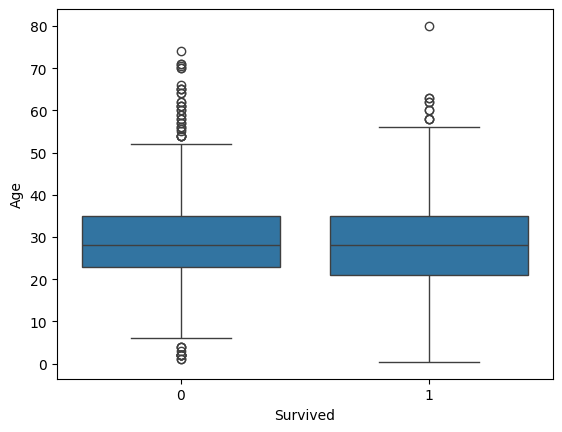

In [21]:
sns.boxplot(x="Survived", y="Age", data=titanic) #Age distribution of passengers

In the box plot above we compare the age distribution of survivors and those that did not survive. Notice that the median ages of the groups are almost the same (just below 28); age was not a strong predictor of survival after all, it seems. Survivors do have slightly longer age spans, which are interesting in that they do contain infants and few old passengers. Both groups contain outliers, consisting of very young infants and older adults.Overall we see considerable overlap between the two box plots - age was a factor, but not as much a contributing factor as passenger class and sex.

In [22]:
Q1 = titanic["Age"].quantile(0.25)
Q3 = titanic["Age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

titanic["Age"] = titanic["Age"].clip(lower, upper)

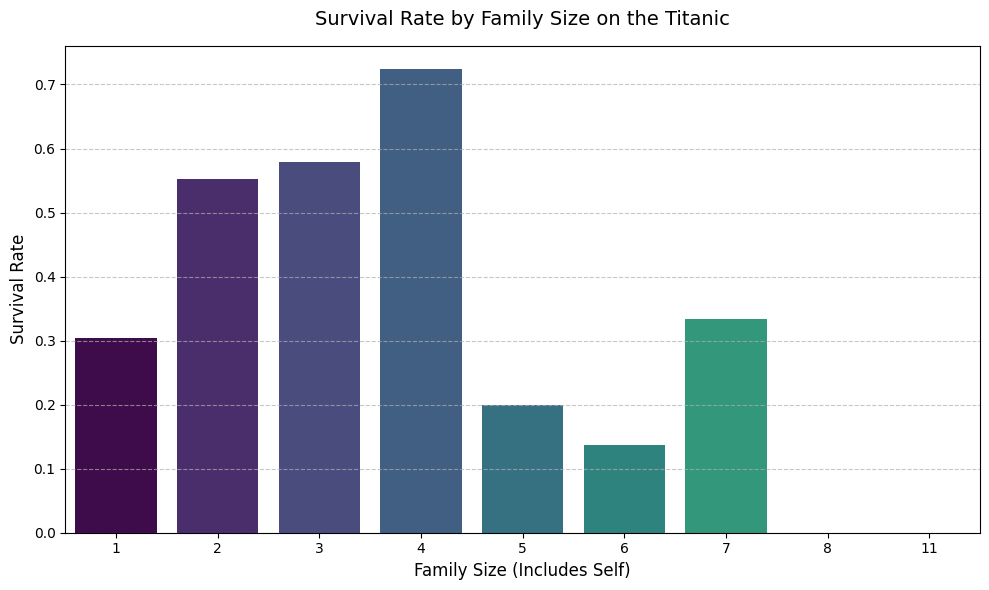

In [23]:
import matplotlib.pyplot as plt

# 2. Calculate Family Size
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1

# 3. Create the Barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=titanic, x='FamilySize', y='Survived', errorbar=None, hue='FamilySize', legend=False, palette='viridis')

# 4. Format the plot
plt.title('Survival Rate by Family Size on the Titanic', fontsize=14, pad=15)
plt.xlabel('Family Size (Includes Self)', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

The bar chart illustrates the survival rate of Titanic passengers based on family size. Passengers traveling in families of four had the highest survival rate (approximately 72%), followed by those in families of three and two, indicating that small to medium-sized families had a better chance of survival. In contrast, passengers traveling alone had a relatively low survival rate (around 30%), while those in large families (five or more members) generally experienced lower survival rates. Overall, the results suggest that family size influenced survival, with moderate-sized families being more likely to survive than individuals traveling alone or passengers in very large families.

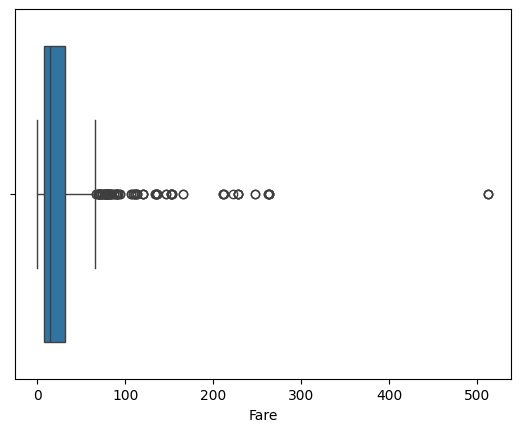

In [24]:
sns.boxplot(x=titanic["Fare"]) #Outliers in fares

Q3 = titanic["Fare"].quantile(0.95)
titanic["Fare"] = titanic["Fare"].apply(lambda x: Q3 if x > Q3 else x)

The box plot shows that the Fare variable contains a large number of high-value outliers. Most passengers paid relatively low fares, as indicated by the narrow box concentrated near the lower end of the scale. However, several passengers paid substantially higher fares, with values extending beyond 500, resulting in numerous outliers on the right side of the plot. This indicates that the Fare distribution is highly positively (right) skewed. These outliers likely represent first-class passengers who purchased expensive tickets and are genuine observations rather than data entry errors. Therefore, they should generally be retained or transformed (e.g., using a logarithmic transformation) rather than removed during data preprocessing.

In [28]:
#Train the dataset using Logistic Regression
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Handle Missing Values
# -----------------------------
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Fare"] = titanic["Fare"].fillna(titanic["Fare"].median())

# Encode categorical variables only if they are not already numeric
if titanic["Sex"].dtype == 'object':
    titanic["Sex"] = titanic["Sex"].map({"male": 0, "female": 1})
if titanic["Embarked"].dtype == 'object':
    titanic["Embarked"] = titanic["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Determine fill values for 'Sex' and 'Embarked' more robustly.
# If the column became all NaNs after mapping, mode() will be empty.
# In that case, use a default (e.g., 0) as the fill value.
sex_mode = titanic["Sex"].mode()
sex_fill_value = sex_mode.iloc[0] if not sex_mode.empty else 0

embarked_mode = titanic["Embarked"].mode()
embarked_fill_value = embarked_mode.iloc[0] if not embarked_mode.empty else 0

titanic["Sex"] = titanic["Sex"].fillna(sex_fill_value)
titanic["Embarked"] = titanic["Embarked"].fillna(embarked_fill_value)

# -----------------------------
# Features and Target
# -----------------------------
X = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = titanic['Survived']

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



# -----------------------------
# Hyperparameter Tuning
# -----------------------------
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2'],
    'max_iter': [1000, 2000, 3000],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

# -----------------------------
# Best Model
# -----------------------------
best_model = grid.best_estimator_

# -----------------------------
# Predictions
# -----------------------------
y_pred = best_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Best Parameters:
{'C': 0.01, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Score:
0.8048458583669852

Accuracy:
0.7821229050279329

Confusion Matrix:
[[99 11]
 [28 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       110
           1       0.79      0.59      0.68        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.77       179



In [31]:
# Train the dataset using Decision Tree
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Fill missing values
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Fare"] = titanic["Fare"].fillna(titanic["Fare"].median())

# Encode categorical columns only if they are not already numeric
if titanic["Sex"].dtype == 'object':
    titanic["Sex"] = titanic["Sex"].map({"male": 0, "female": 1})
if titanic["Embarked"].dtype == 'object':
    titanic["Embarked"] = titanic["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Determine fill values for 'Sex' and 'Embarked' more robustly.
# If the column became all NaNs after mapping, mode() will be empty.
# In that case, use a default (e.g., 0) as the fill value.
sex_mode = titanic["Sex"].mode()
sex_fill_value = sex_mode.iloc[0] if not sex_mode.empty else 0

embarked_mode = titanic["Embarked"].mode()
embarked_fill_value = embarked_mode.iloc[0] if not embarked_mode.empty else 0

titanic["Sex"] = titanic["Sex"].fillna(sex_fill_value)
titanic["Embarked"] = titanic["Embarked"].fillna(embarked_fill_value)

# Features and Target
X = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = titanic['Survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Hyperparameter Tuning
# -----------------------------
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

# -----------------------------
# Best Model
# -----------------------------
best_model = grid.best_estimator_

# -----------------------------
# Prediction
# -----------------------------
y_pred = best_model.predict(X_test)

# Create a DataFrame for the sample prediction to retain feature names
sample_df = pd.DataFrame([[3, 0, 62.0, 0, 0, titanic["Fare"].median(), 0]], columns=X.columns)
sample_scaled = scaler.transform(sample_df) # Assuming scaler is defined and fitted earlier in the notebook

print("\nPrediction for a 62-year-old passenger:")
print(best_model.predict(sample_scaled))

# -----------------------------
# Evaluation
# -----------------------------
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# Feature Importance
# -----------------------------
print("\nFeature Importance:")
for feature, importance in zip(
    ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'],
    best_model.feature_importances_
):
    print(f"{feature}: {importance:.4f}")

Best Parameters:
{'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}

Best Cross Validation Accuracy:
0.8244558258642766

Prediction for a 62-year-old passenger:
[1]

Accuracy:
0.8044692737430168

Confusion Matrix:
[[89 16]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179


Feature Importance:
Pclass: 0.1948
Sex: 0.4124
Age: 0.1510
SibSp: 0.0521
Parch: 0.0000
Fare: 0.1675
Embarked: 0.0222


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [35]:
#Train using RandomForest

import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Fill Missing Values
# -----------------------------
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Fare"] = titanic["Fare"].fillna(titanic["Fare"].median())

# Encode categorical variables
if titanic["Sex"].dtype == "object":
    titanic["Sex"] = titanic["Sex"].map({"male":0, "female":1})

if titanic["Embarked"].dtype == "object":
    titanic["Embarked"] = titanic["Embarked"].map({"S":0, "C":1, "Q":2})

# Fill remaining missing values
titanic["Sex"] = titanic["Sex"].fillna(titanic["Sex"].mode()[0])
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

# -----------------------------
# Features and Target
# -----------------------------
X = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = titanic['Survived']

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Hyperparameter Tuning
# -----------------------------
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

# -----------------------------
# Best Model
# -----------------------------
best_model = grid.best_estimator_

# -----------------------------
# Prediction
# -----------------------------
y_pred = best_model.predict(X_test)

# Sample prediction
sample = pd.DataFrame(
    [[3, 0, 62, 0, 0, titanic["Fare"].median(), 0]],
    columns=X.columns
)

prediction = best_model.predict(sample)

print("\nPrediction for 62-year-old passenger:")
print("Survived" if prediction[0] == 1 else "Did Not Survive")

# -----------------------------
# Evaluation
# -----------------------------
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

Best Parameters:
{'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}

Best Cross Validation Accuracy:
0.8329656259233724

Prediction for 62-year-old passenger:
Did Not Survive

Accuracy:
0.7988826815642458

Confusion Matrix:
[[98 12]
 [24 45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179


Feature Importance:
    Feature  Importance
1       Sex    0.344502
5      Fare    0.235387
2       Age    0.177242
0    Pclass    0.117228
3     SibSp    0.050119
4     Parch    0.038291
6  Embarked    0.037230


In [36]:
#Train using Support vector classifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# -----------------------------
# Handle Missing Values
# -----------------------------
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Fare"] = titanic["Fare"].fillna(titanic["Fare"].median())

# -----------------------------
# Encode Categorical Variables
# -----------------------------
# Encode categorical variables only if they are not already numeric
if titanic["Sex"].dtype == 'object':
    titanic["Sex"] = titanic["Sex"].map({"male": 0, "female": 1})
if titanic["Embarked"].dtype == 'object':
    titanic["Embarked"] = titanic["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Determine fill values for 'Sex' and 'Embarked' more robustly.
# If the column became all NaNs after mapping, mode() will be empty.
# In that case, use a default (e.g., 0) as the fill value.
sex_mode = titanic["Sex"].mode()
sex_fill_value = sex_mode.iloc[0] if not sex_mode.empty else 0

embarked_mode = titanic["Embarked"].mode()
embarked_fill_value = embarked_mode.iloc[0] if not embarked_mode.empty else 0

titanic["Sex"] = titanic["Sex"].fillna(sex_fill_value)
titanic["Embarked"] = titanic["Embarked"].fillna(embarked_fill_value)

# -----------------------------
# Features and Target
# -----------------------------
X = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = titanic['Survived']

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Hyperparameter Tuning
# -----------------------------
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

# -----------------------------
# Best Model
# -----------------------------
best_model = grid.best_estimator_

# -----------------------------
# Prediction
# -----------------------------
y_pred = best_model.predict(X_test)

# Create a DataFrame for the sample prediction to retain feature names
sample_df = pd.DataFrame([[3, 0, 62.0, 0, 0, titanic["Fare"].median(), 0]], columns=X.columns)
sample_scaled = scaler.transform(sample_df)

print("\nPrediction for a 62-year-old passenger:")
print(best_model.predict(sample_scaled))

# -----------------------------
# Evaluation
# -----------------------------
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Parameters:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Best Cross Validation Accuracy:
0.8258938244853737

Prediction for a 62-year-old passenger:
[0]

Accuracy:
0.7932960893854749

Confusion Matrix:
[[100  10]
 [ 27  42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       110
           1       0.81      0.61      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179

